# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

In [35]:
import random
class Card:
    def __init__(self,suit,value):
        self.suit = suit
        self.value = value

    def get_value(self):
        if self.value not in ['J','Q','K','A']:
            return int(self.value)
        elif self.value in ['J','Q','K']:
            return 10
        else:
            return 11

In [36]:
class Decks:
    def __init__(self,decks=6):
        self.decks = decks
        self.cards = []
        self.plastic_card = None
        self.build_deck()

    def build_deck(self):
        suits = ['Clubs', 'Spades', 'Hearts', 'Diamonds']
        values = ['2', '3', '4', '5', '6', '7', '8', '9', '10', 'J', 'Q', 'K', 'A']
        self.cards = [Card(suit, value) for _ in range(self.decks) for suit in suits for value in values]
        self.shuffle()
        self.insert_plastic_card()

    def shuffle(self):
        n = len(self.cards)
        for i in range(n - 1, 0, -1):
            j = random.randint(0, i)
            self.cards[i], self.cards[j] = self.cards[j], self.cards[i]

    def insert_plastic_card(self):
        position = random.randint(int(len(self.cards) * 0.6), int(len(self.cards) * 0.75))
        self.plastic_card = position
        return self.plastic_card

    def draw_card(self):
        if len(self.cards) == 0:
            print("Rebuilding empty deck")
            self.build_deck()
        card = self.cards[0]
        self.cards = self.cards[1:]
        if len(self.cards) == self.plastic_card:
            print("Plastic card found, reshuffling")
            self.build_deck()
        return card

    def remaining_cards(self):
        return len(self.cards)



2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

In [42]:
class Hand:
    def __init__(self):
        self.cards = []

    def add_card(self, card):
        pass

    def get_total(self):
        pass

    def is_blackjack(self):
        pass

    def is_bust(self):
        pass

In [43]:
class Player:
    def __init__(self, name, chips=1000, strategy="basic"):
        self.name = name
        self.hand = Hand()
        self.chips = chips
        self.strategy = strategy

    def make_move(self, dealer_card):
        pass

    def place_bet(self):
        pass

    def reset_hand(self):
        pass

In [44]:
class Dealer:
    def __init__(self):
        self.hand = Hand()

    def play(self):
        pass

    def reset_hand(self):
        pass

In [45]:
class BlackjackGame:
    def __init__(self, num_players=1):
        self.deck = Decks()
        self.players = [Player(f"Player {i+1}") for i in range(num_players)]
        self.dealer = Dealer()

    def play_round(self):
        pass

    def run_simulation(self,n):
        pass

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

In [46]:
class Player:
    def __init__(self, name, chips=1000, strategy="basic"):
        self.name = name
        self.hand = Hand()
        self.chips = chips
        self.strategy = strategy

    def make_move(self,dealer_card):
        while True:
            print(f"\n{self.name}'s hand: {[f'{c.value} of {c.suit}' for c in self.hand.cards]} (Total: {self.hand.get_total()})")
            print(f"Dealer shows: {dealer_card.value} of {dealer_card.suit}")
            choice = input("Hit or stand? ").strip().lower()
            if choice == 'hit':
                return "hit"
            elif choice == 'stand':
                return "stand"
            else:
                print("Invalid input. Please type 'hit' or 'stand'.")

    def place_bet(self):
        self.current_bet = 10
        self.chips -= self.current_bet
        return self.current_bet

    def reset_hand(self):
        self.hand = Hand()

In [47]:
class BotPlayer(Player):
    def make_move(self, dealer_card):
        while self.hand.get_total() < 17:
            print(f"{self.name} hits")
            return "hit"
        print(f"{self.name} stands")
        return "stand"

In [48]:
class Dealer:
    def __init__(self):
        self.hand = Hand()

    def play(self, deck):
        while self.hand.get_total() < 17:
            self.hand.add_card(deck.draw_card())

    def reset_hand(self):
        self.hand = Hand()

5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

In [49]:
class Hand:
    def __init__(self):
        self.cards = []

    def add_card(self, card):
        self.cards.append(card)

    def get_total(self):
        total = 0
        aces = 0
        for card in self.cards:
            val = card.get_value()
            total += val
            if card.value == 'A':
                aces += 1
        while total > 21 and aces > 0:
            total -= 10
            aces -= 1
        return total

    def is_blackjack(self):
        return len(self.cards) == 2 and self.get_total() == 21

    def is_bust(self):
        return self.get_total() > 21

In [50]:
class BlackjackGame:
    def __init__(self,num_players=1):
        self.deck = Decks()
        self.players = [Player(f"Player {i+1}") for i in range(num_players)]
        self.dealer = Dealer()

    def reset_round(self):
        for player in self.players:
            player.reset_hand()
            player.place_bet()
            player.hand.add_card(self.deck.draw_card())
            player.hand.add_card(self.deck.draw_card())
        self.dealer.reset_hand()
        self.dealer.hand.add_card(self.deck.draw_card())
        self.dealer.hand.add_card(self.deck.draw_card())

    def play_players(self,dealer_show_card):
        for player in self.players:
            print(f"\n{player.name}'s turn")
            while True:
                move = player.make_move(dealer_show_card)
                if move == "hit":
                    new_card = self.deck.draw_card()
                    print(f"{player.name} draws: {new_card.value} of {new_card.suit}")
                    player.hand.add_card(new_card)
                    if player.hand.is_bust():
                        print(f"{player.name} busts")
                        break
                elif move == "stand":
                    print(f"{player.name} stands")
                    break

    def resolve_results(self):
        dealer_total = self.dealer.hand.get_total()
        print("\nDealer's hand:", [f"{c.value} of {c.suit}" for c in self.dealer.hand.cards])
        print(f"Dealer's total: {dealer_total}")
        for player in self.players:
            player_total = player.hand.get_total()
            print(f"\n{player.name}'s total: {player_total}")
            if player.hand.is_bust():
                print(f"{player.name} loses")
            elif self.dealer.hand.is_bust() or player_total > dealer_total:
                print(f"{player.name} wins")
                player.chips += player.current_bet * 2
            elif player_total == dealer_total:
                print(f"{player.name} pushes")
                player.chips += player.current_bet
            else:
                print(f"{player.name} loses")
            print(f"{player.name}'s chips: {player.chips}")

    def play_round(self):
        print("\n--- New Round ---")
        self.reset_round()
        dealer_show_card = self.dealer.hand.cards[0]
        print(f"Dealer shows: {dealer_show_card.value} of {dealer_show_card.suit}")
        self.play_players(dealer_show_card)
        print("\nDealer's turn:")
        self.dealer.play(self.deck)
        self.resolve_results()

    def run_game(self, n):
        for i in range(n):
            print(f"\n=== Round {i+1} ===")
            self.play_round()


In [51]:
### game with 3 bots, 1 dealer
game = BlackjackGame(num_players=3)
game.players = [BotPlayer("Bot 1"),BotPlayer("Bot 2"),BotPlayer("Bot 3")]
game.run_game(3)


=== Round 1 ===

--- New Round ---
Dealer shows: 6 of Spades

Bot 1's turn
Bot 1 stands
Bot 1 stands

Bot 2's turn
Bot 2 stands
Bot 2 stands

Bot 3's turn
Bot 3 stands
Bot 3 stands

Dealer's turn:

Dealer's hand: ['6 of Spades', '10 of Diamonds', '6 of Spades']
Dealer's total: 22

Bot 1's total: 19
Bot 1 wins
Bot 1's chips: 1010

Bot 2's total: 20
Bot 2 wins
Bot 2's chips: 1010

Bot 3's total: 17
Bot 3 wins
Bot 3's chips: 1010

=== Round 2 ===

--- New Round ---
Dealer shows: K of Diamonds

Bot 1's turn
Bot 1 hits
Bot 1 draws: 9 of Spades
Bot 1 hits
Bot 1 draws: A of Clubs
Bot 1 hits
Bot 1 draws: 7 of Diamonds
Bot 1 stands
Bot 1 stands

Bot 2's turn
Bot 2 stands
Bot 2 stands

Bot 3's turn
Bot 3 stands
Bot 3 stands

Dealer's turn:

Dealer's hand: ['K of Diamonds', '9 of Diamonds']
Dealer's total: 19

Bot 1's total: 21
Bot 1 wins
Bot 1's chips: 1020

Bot 2's total: 20
Bot 2 wins
Bot 2's chips: 1020

Bot 3's total: 20
Bot 3 wins
Bot 3's chips: 1020

=== Round 3 ===

--- New Round ---
Dea

6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

In [95]:
class CountingPlayer(Player):
    def __init__(self, name, chips=1000, threshold=-2):
        super().__init__(name, chips, strategy="counting")
        self.count = 0
        self.threshold = threshold

    def check_card(self,card):
        if card.value in ['2','3','4','5','6']:
            self.count += 1
        elif card.value in ['10','J','Q','K','A']:
            self.count -= 1

    def make_move(self, dealer_card):
        #print(f"{self.name}")
        if self.hand.get_total() < 21 and self.count <= self.threshold:
            #print(f"{self.name} hits")
            return "hit"
        else:
            #print(f"{self.name} stands")
            return "stand"

In [96]:
class Player:
    def __init__(self, name, chips=1000, strategy="basic"):
        self.name = name
        self.hand = Hand()
        self.chips = chips
        self.strategy = strategy

    def make_move(self,dealer_card):
        while True:
            #print(f"\n{self.name}'s hand: {[f'{c.value} of {c.suit}' for c in self.hand.cards]} (Total: {self.hand.get_total()})")
            #print(f"Dealer shows: {dealer_card.value} of {dealer_card.suit}")
            choice = input("Hit or stand? ").strip().lower()
            if choice == 'hit':
                return "hit"
            elif choice == 'stand':
                return "stand"
            else:
                print("Invalid input. Please type 'hit' or 'stand'.")

    def place_bet(self):
        self.current_bet = 10
        self.chips -= self.current_bet
        return self.current_bet

    def reset_hand(self):
        self.hand = Hand()

In [97]:
class BotPlayer(Player):
    def make_move(self, dealer_card):
        while self.hand.get_total() < 17:
            #print(f"{self.name} hits")
            return "hit"
        #print(f"{self.name} stands")
        return "stand"

In [98]:
class Dealer:
    def __init__(self):
        self.hand = Hand()

    def play(self, deck, players):
        while self.hand.get_total() < 17:
            card = deck.draw_card()
            self.hand.add_card(card)
            for player in players:
                if isinstance(player, CountingPlayer):
                    player.check_card(card)

    def reset_hand(self):
        self.hand = Hand()

In [99]:
class BlackjackGame:
    def __init__(self, num_players=1):
        self.deck = Decks()
        self.players = [Player(f"Player {i+1}") for i in range(num_players)]
        self.dealer = Dealer()

    def reset_round(self):
        for player in self.players:
            player.reset_hand()
            player.place_bet()
            for _ in range(2):
                card = self.deck.draw_card()
                player.hand.add_card(card)
                if isinstance(player, CountingPlayer):
                    player.check_card(card)
        self.dealer.reset_hand()
        for _ in range(2):
            card = self.deck.draw_card()
            self.dealer.hand.add_card(card)
            for player in self.players:
                if isinstance(player, CountingPlayer):
                    player.check_card(card)

    def play_players(self, dealer_show_card):
        for player in self.players:
            #print(f"\n{player.name}'s turn")
            while True:
                move = player.make_move(dealer_show_card)
                if move == "hit":
                    card = self.deck.draw_card()
                    player.hand.add_card(card)
                    if isinstance(player, CountingPlayer):
                        player.check_card(card)
                    if player.hand.is_bust():
                        #print(f"{player.name} busts")
                        break
                elif move == "stand":
                    #print(f"{player.name} stands")
                    break

    def resolve_results(self):
        dealer_total = self.dealer.hand.get_total()
        #print("\nDealer's hand:", [f"{c.value} of {c.suit}" for c in self.dealer.hand.cards])
        #print(f"Dealer's total: {dealer_total}")
        for player in self.players:
            player_total = player.hand.get_total()
           # print(f"\n{player.name}'s total: {player_total}")
            if player.hand.is_bust():
                #print(f"{player.name} loses")
                continue
            elif self.dealer.hand.is_bust() or player_total > dealer_total:
                #print(f"{player.name} wins")
                player.chips += player.current_bet * 2
            elif player_total == dealer_total:
                #print(f"{player.name} pushes")
                player.chips += player.current_bet
            else:
                #print(f"{player.name} loses")
                continue
            #print(f"{player.name}'s chips: {player.chips}")

    def play_round(self):
        #print("\n--- New Round ---")
        self.reset_round()
        dealer_show_card = self.dealer.hand.cards[0]
        #print(f"Dealer shows: {dealer_show_card.value} of {dealer_show_card.suit}")
        self.play_players(dealer_show_card)
        #print("\nDealer's turn:")
        self.dealer.play(self.deck, self.players)
        self.resolve_results()

    def run_simulation(self, n):
        for i in range(n):
           # print(f"\n=== Round {i+1} ===")
            self.play_round()




7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

In [101]:
game = BlackjackGame(num_players=4)
strat_bot = CountingPlayer("StrategyBot",threshold=-2)
game.players = [BotPlayer("Bot 1"),BotPlayer("Bot 2"),BotPlayer("Bot 3"),strat_bot]
initial_chips = strat_bot.chips
for n in range(50):
    if strat_bot.chips <= 0:
        print(f"\n{strat_bot.name} loses after {n} rounds.")
        break
    game.play_round()
print(f"\n{strat_bot.name}'s final chips: {strat_bot.chips}")
print(f"Winnings: {strat_bot.chips - initial_chips}")

Plastic card found, reshuffling
Plastic card found, reshuffling
Plastic card found, reshuffling
Plastic card found, reshuffling
Plastic card found, reshuffling
Plastic card found, reshuffling

StrategyBot's final chips: 950
Winnings: -50


8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


In [105]:
class Decks:
    def __init__(self,decks=6):
        self.decks = decks
        self.cards = []
        self.plastic_card = None
        self.build_deck()

    def build_deck(self):
        suits = ['Clubs', 'Spades', 'Hearts', 'Diamonds']
        values = ['2', '3', '4', '5', '6', '7', '8', '9', '10', 'J', 'Q', 'K', 'A']
        self.cards = [Card(suit, value) for _ in range(self.decks) for suit in suits for value in values]
        self.shuffle()
        self.insert_plastic_card()

    def shuffle(self):
        n = len(self.cards)
        for i in range(n - 1, 0, -1):
            j = random.randint(0, i)
            self.cards[i], self.cards[j] = self.cards[j], self.cards[i]

    def insert_plastic_card(self):
        position = random.randint(int(len(self.cards) * 0.6), int(len(self.cards) * 0.75))
        self.plastic_card = position
        return self.plastic_card

    def draw_card(self):
        if len(self.cards) == 0:
           # print("Rebuilding empty deck")
            self.build_deck()
        card = self.cards[0]
        self.cards = self.cards[1:]
        if len(self.cards) == self.plastic_card:
            #print("Plastic card found, reshuffling")
            self.build_deck()
        return card

    def remaining_cards(self):
        return len(self.cards)



In [109]:
final_chips = []
for m in range(100):
    game = BlackjackGame(num_players=4)
    strat_bot = CountingPlayer("StrategyBot",threshold=-2)
    game.players = [BotPlayer("Bot 1"),BotPlayer("Bot 2"),BotPlayer("Bot 3"),strat_bot]
    initial_chips = strat_bot.chips
    for n in range(50):
        if strat_bot.chips <= 0:
            print(f"\n{strat_bot.name} loses after {n} rounds.")
            break
        game.play_round()
    final_chips.append(strat_bot.chips - initial_chips)

In [110]:
len(final_chips)

100

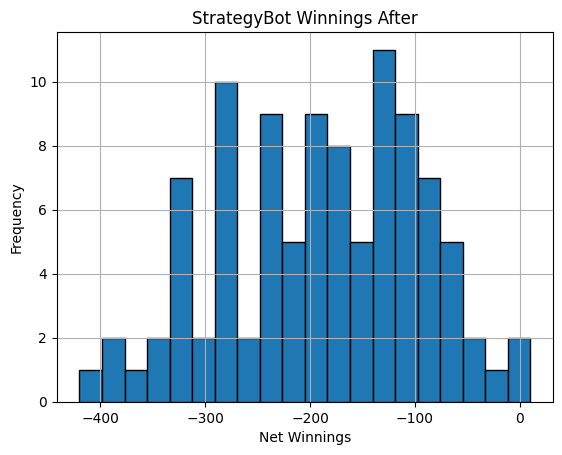

Average winnings: -190.0
Standard deviation: 94.2443632266673
Probability of net win: 0.01
Probability of net loss: 0.98


In [111]:
import matplotlib.pyplot as plt
import numpy as np
plt.hist(final_chips, bins=20, edgecolor='black')
plt.title("StrategyBot Winnings After")
plt.xlabel("Net Winnings")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

avg = np.mean(final_chips)
std = np.std(final_chips)
p_win = np.mean(np.array(final_chips) > 0)
p_loss = np.mean(np.array(final_chips) < 0)

print(f"Average winnings: {avg}")
print(f"Standard deviation: {std}")
print(f"Probability of net win: {p_win}")
print(f"Probability of net loss: {p_loss}")

9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

In [139]:
def test_thresh(threshold_range,num_games=100,rounds_per_game=50):
    avg_winnings = []
    thresholds = list(threshold_range)
    for threshold in thresholds:
        winnings = []
        for _ in range(num_games):
            game = BlackjackGame(num_players=4)
            strat_bot = CountingPlayer("StrategyBot", threshold=threshold)
            game.players = [BotPlayer("Bot 1"),BotPlayer("Bot 2"),BotPlayer("Bot 3"),strat_bot]
            initial_chips = strat_bot.chips
            for _ in range(rounds_per_game):
                if strat_bot.chips <= 0:
                    break
                game.play_round()
            winnings.append(strat_bot.chips - initial_chips)
        avg_win = np.mean(winnings)
        print(f"Threshold: {threshold} | Winnings: {avg_win}")
        avg_winnings.append(avg_win)
    return avg_winnings


In [140]:
avg_winnings = test_thresh(range(-5, 6))

Threshold: -5 | Winnings: -154.5
Threshold: -4 | Winnings: -171.9
Threshold: -3 | Winnings: -178.9
Threshold: -2 | Winnings: -193.5
Threshold: -1 | Winnings: -198.7
Threshold: 0 | Winnings: -214.0
Threshold: 1 | Winnings: -224.1
Threshold: 2 | Winnings: -239.4
Threshold: 3 | Winnings: -245.0
Threshold: 4 | Winnings: -244.5
Threshold: 5 | Winnings: -246.6


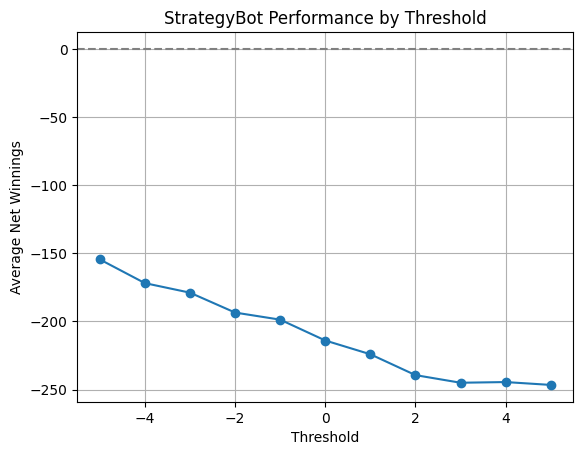

In [141]:
thresholds = [-5,-4,-3,-2,-1,0,1,2,3,4,5]
plt.plot(thresholds, avg_winnings, marker='o')
plt.axhline(0, color='gray', linestyle='--')
plt.title("StrategyBot Performance by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Average Net Winnings")
plt.grid(True)
plt.show()

10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

In [151]:
### this "strategy" just hits every nth card drawn
class Hit_n(Player):
    def __init__(self, name, chips=1000, n=5):
        super().__init__(name, chips, strategy=f"hit_every_{n}")
        self.card_counter = 0
        self.n = n

    def check_card(self, card):
        self.card_counter += 1

    def make_move(self, dealer_card):
        if self.card_counter % self.n == 0:
            print(f"{self.name} hits (every {self.n}th card rule!)")
            return "hit"
        total = self.hand.get_total()
        return "hit" if total < 17 else "stand"

In [152]:
class Dealer:
    def __init__(self):
        self.hand = Hand()

    def play(self, deck, players):
        while self.hand.get_total() < 17:
            card = deck.draw_card()
            self.hand.add_card(card)
            for player in players:
                if isinstance(player,(CountingPlayer,Hit_n)):
                    player.check_card(card)
                    
    def reset_hand(self):
        self.hand = Hand()

In [153]:
class BlackjackGame:
    def __init__(self, num_players=1):
        self.deck = Decks()
        self.players = [Player(f"Player {i+1}") for i in range(num_players)]
        self.dealer = Dealer()

    def reset_round(self):
        for player in self.players:
            player.reset_hand()
            player.place_bet()
            for _ in range(2):
                card = self.deck.draw_card()
                player.hand.add_card(card)
                if isinstance(player,(CountingPlayer,Hit_n)):
                    player.check_card(card)
        self.dealer.reset_hand()
        for _ in range(2):
            card = self.deck.draw_card()
            self.dealer.hand.add_card(card)
            for player in self.players:
                if isinstance(player,(CountingPlayer,Hit_n)):
                    player.check_card(card)

    def play_players(self, dealer_show_card):
        for player in self.players:
            #print(f"\n{player.name}'s turn")
            while True:
                move = player.make_move(dealer_show_card)
                if move == "hit":
                    card = self.deck.draw_card()
                    player.hand.add_card(card)
                    if isinstance(player,(CountingPlayer,Hit_n)):
                        player.check_card(card)
                    if player.hand.is_bust():
                        #print(f"{player.name} busts")
                        break
                elif move == "stand":
                    #print(f"{player.name} stands")
                    break

    def resolve_results(self):
        dealer_total = self.dealer.hand.get_total()
        #print("\nDealer's hand:", [f"{c.value} of {c.suit}" for c in self.dealer.hand.cards])
        #print(f"Dealer's total: {dealer_total}")
        for player in self.players:
            player_total = player.hand.get_total()
           # print(f"\n{player.name}'s total: {player_total}")
            if player.hand.is_bust():
                #print(f"{player.name} loses")
                continue
            elif self.dealer.hand.is_bust() or player_total > dealer_total:
                #print(f"{player.name} wins")
                player.chips += player.current_bet * 2
            elif player_total == dealer_total:
                #print(f"{player.name} pushes")
                player.chips += player.current_bet
            else:
                #print(f"{player.name} loses")
                continue
            #print(f"{player.name}'s chips: {player.chips}")

    def play_round(self):
        #print("\n--- New Round ---")
        self.reset_round()
        dealer_show_card = self.dealer.hand.cards[0]
        #print(f"Dealer shows: {dealer_show_card.value} of {dealer_show_card.suit}")
        self.play_players(dealer_show_card)
        #print("\nDealer's turn:")
        self.dealer.play(self.deck, self.players)
        self.resolve_results()

    def run_simulation(self, n):
        for i in range(n):
           # print(f"\n=== Round {i+1} ===")
            self.play_round()




In [154]:
def test_n(threshold_range,num_games=100,rounds_per_game=50):
    avg_winnings = []
    thresholds = list(threshold_range)
    for threshold in thresholds:
        winnings = []
        for _ in range(num_games):
            game = BlackjackGame(num_players=4)
            strat_bot = Hit_n("HitBot",n=n)
            game.players = [BotPlayer("Bot 1"),BotPlayer("Bot 2"),BotPlayer("Bot 3"),strat_bot]
            initial_chips = strat_bot.chips
            for _ in range(rounds_per_game):
                if strat_bot.chips <= 0:
                    break
                game.play_round()
            winnings.append(strat_bot.chips - initial_chips)
        avg_win = np.mean(winnings)
        print(f"Threshold: {threshold} | Winnings: {avg_win}")
        avg_winnings.append(avg_win)
    return avg_winnings

In [157]:
avg_winnings = test_thresh(range(1, 16))

Threshold: 1 | Winnings: -201.5
Threshold: 2 | Winnings: -234.9
Threshold: 3 | Winnings: -240.7
Threshold: 4 | Winnings: -255.7
Threshold: 5 | Winnings: -256.3
Threshold: 6 | Winnings: -264.4
Threshold: 7 | Winnings: -261.7
Threshold: 8 | Winnings: -268.1
Threshold: 9 | Winnings: -289.2
Threshold: 10 | Winnings: -290.9
Threshold: 11 | Winnings: -284.1
Threshold: 12 | Winnings: -318.7
Threshold: 13 | Winnings: -309.8
Threshold: 14 | Winnings: -309.2
Threshold: 15 | Winnings: -315.3


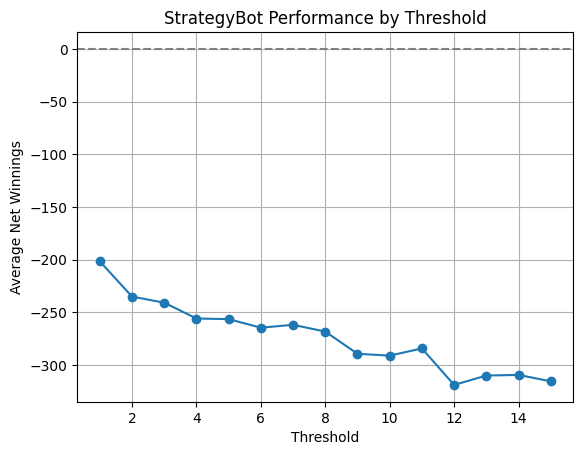

In [158]:
n = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
plt.plot(n, avg_winnings, marker='o')
plt.axhline(0, color='gray', linestyle='--')
plt.title("StrategyBot Performance by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Average Net Winnings")
plt.grid(True)
plt.show()